In [ ]:
pip install opendatasets

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/competitions/cloud-type-classification2/data')

100%|██████████| 1.70G/1.70G [00:12<00:00, 143MB/s]



Extracting archive ./cloud-type-classification2/cloud-type-classification2.zip to ./cloud-type-classification2


In [ ]:
import os
os.listdir('cloud-type-classification2')

['submit.csv', 'images', 'test.csv', 'train.csv']

In [ ]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import os

class CloudTypeDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        # Assuming image file names are in the first column
        self.img_names = self.annotations.iloc[:, 0].values

        # Check if there's a second column (index 1) for labels
        if self.annotations.shape[1] > 1:
            unique_labels = sorted(self.annotations.iloc[:, 1].unique())
            self.label_map = {label: i for i, label in enumerate(unique_labels)}
            self.labels = [self.label_map[label] for label in self.annotations.iloc[:, 1].values]
            self.has_labels = True
        else:
            # For test set without labels, provide dummy labels (e.g., 0)
            self.labels = [0] * len(self.annotations)
            self.has_labels = False

        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

train_transform = transforms.Compose([
    transforms.Resize((128,128)), # Resize first
    transforms.ToTensor()
])

# Define paths for the CSV and image directory
train_csv_path = '/content/cloud-type-classification2/train.csv'
train_img_dir = '/content/cloud-type-classification2/images/train'

dataset_train = CloudTypeDataset(
    csv_file=train_csv_path,
    img_dir=train_img_dir,
    transform=train_transform
)

In [ ]:
from torch.utils.data import DataLoader
dataloader_train = DataLoader(dataset_train,batch_size=1,shuffle=True)

In [ ]:
image,label = next(iter(dataloader_train))

print(image.shape)
print(label.shape)

torch.Size([1, 3, 128, 128])
torch.Size([1])


In [ ]:
image = image.squeeze().permute(1,2,0)

print(image.shape)

torch.Size([128, 128, 3])


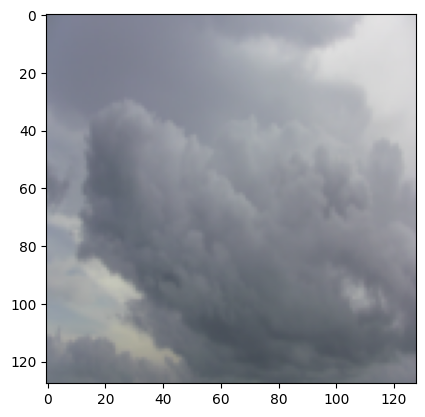

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class Net(nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    self.feature_extractor = nn.Sequential(
        nn.Conv2d(3,32,kernel_size = 3,padding =1),
        nn.ELU(),
        nn.MaxPool2d(kernel_size = 2,stride = 2),
        nn.Conv2d(32,64,kernel_size = 3,padding =1),
        nn.ELU(),
        nn.MaxPool2d(kernel_size = 2,stride = 2),
        nn.Flatten()
    )

    self.classifier = nn.Linear(64*32*32,num_classes)
  def forward(self,x):
    x = self.feature_extractor(x)
    x = self.classifier(x)
    return x

In [ ]:
import torch.optim as optim
net = Net(num_classes =7)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr = 0.001)

for epoch in range(10):
  for images,labels in dataloader_train:
    optimizer.zero_grad()
    outputs = net(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

test_csv_path = '/content/cloud-type-classification2/test.csv'
test_img_dir = '/content/cloud-type-classification2/images/test'

dataset_test = CloudTypeDataset(
    csv_file=test_csv_path,
    img_dir=test_img_dir,
    transform=test_transform
)

from torch.utils.data import DataLoader
dataloader_test = DataLoader(dataset_test,batch_size=1,shuffle=False)

In [ ]:
!pip install torchmetrics
from torchmetrics import Precision,Recall

metric_precision = Precision(task = 'multiclass',num_classes = 7,average = 'macro')
metric_recall = Recall(task = 'multiclass',num_classes = 7,average = 'macro')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 49.7 MB/s eta 0:00:00


In [ ]:
net.eval()

with torch.no_grad():
  for images,labels in dataloader_test:
    outputs = net(images)
    _,preds = torch.max(outputs,1)
    metric_precision(preds,labels)
    metric_recall(preds,labels)

precision = metric_precision.compute()
recall = metric_recall.compute()


In [ ]:
precision

tensor(0.1429)

In [ ]:
recall

tensor(0.0022)